In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


df = pd.read_csv('penguins_lter.csv')
df.head(6)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [23]:
df=df.dropna(axis=0,subset='Sex')

In [24]:
# Eliminamos columna comments
df = df.drop(columns=['Comments'])

In [25]:
# Eliminamos entradas con valores nulos en las columnas Delta 15 i Delta 13 C
df = df.dropna(subset=['Delta 15 N (o/oo)', 'Delta 13 C (o/oo)'])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 1 to 343
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            325 non-null    object 
 1   Sample Number        325 non-null    int64  
 2   Species              325 non-null    object 
 3   Region               325 non-null    object 
 4   Island               325 non-null    object 
 5   Stage                325 non-null    object 
 6   Individual ID        325 non-null    object 
 7   Clutch Completion    325 non-null    object 
 8   Date Egg             325 non-null    object 
 9   Culmen Length (mm)   325 non-null    float64
 10  Culmen Depth (mm)    325 non-null    float64
 11  Flipper Length (mm)  325 non-null    float64
 12  Body Mass (g)        325 non-null    float64
 13  Sex                  325 non-null    object 
 14  Delta 15 N (o/oo)    325 non-null    float64
 15  Delta 13 C (o/oo)    325 non-null    float64


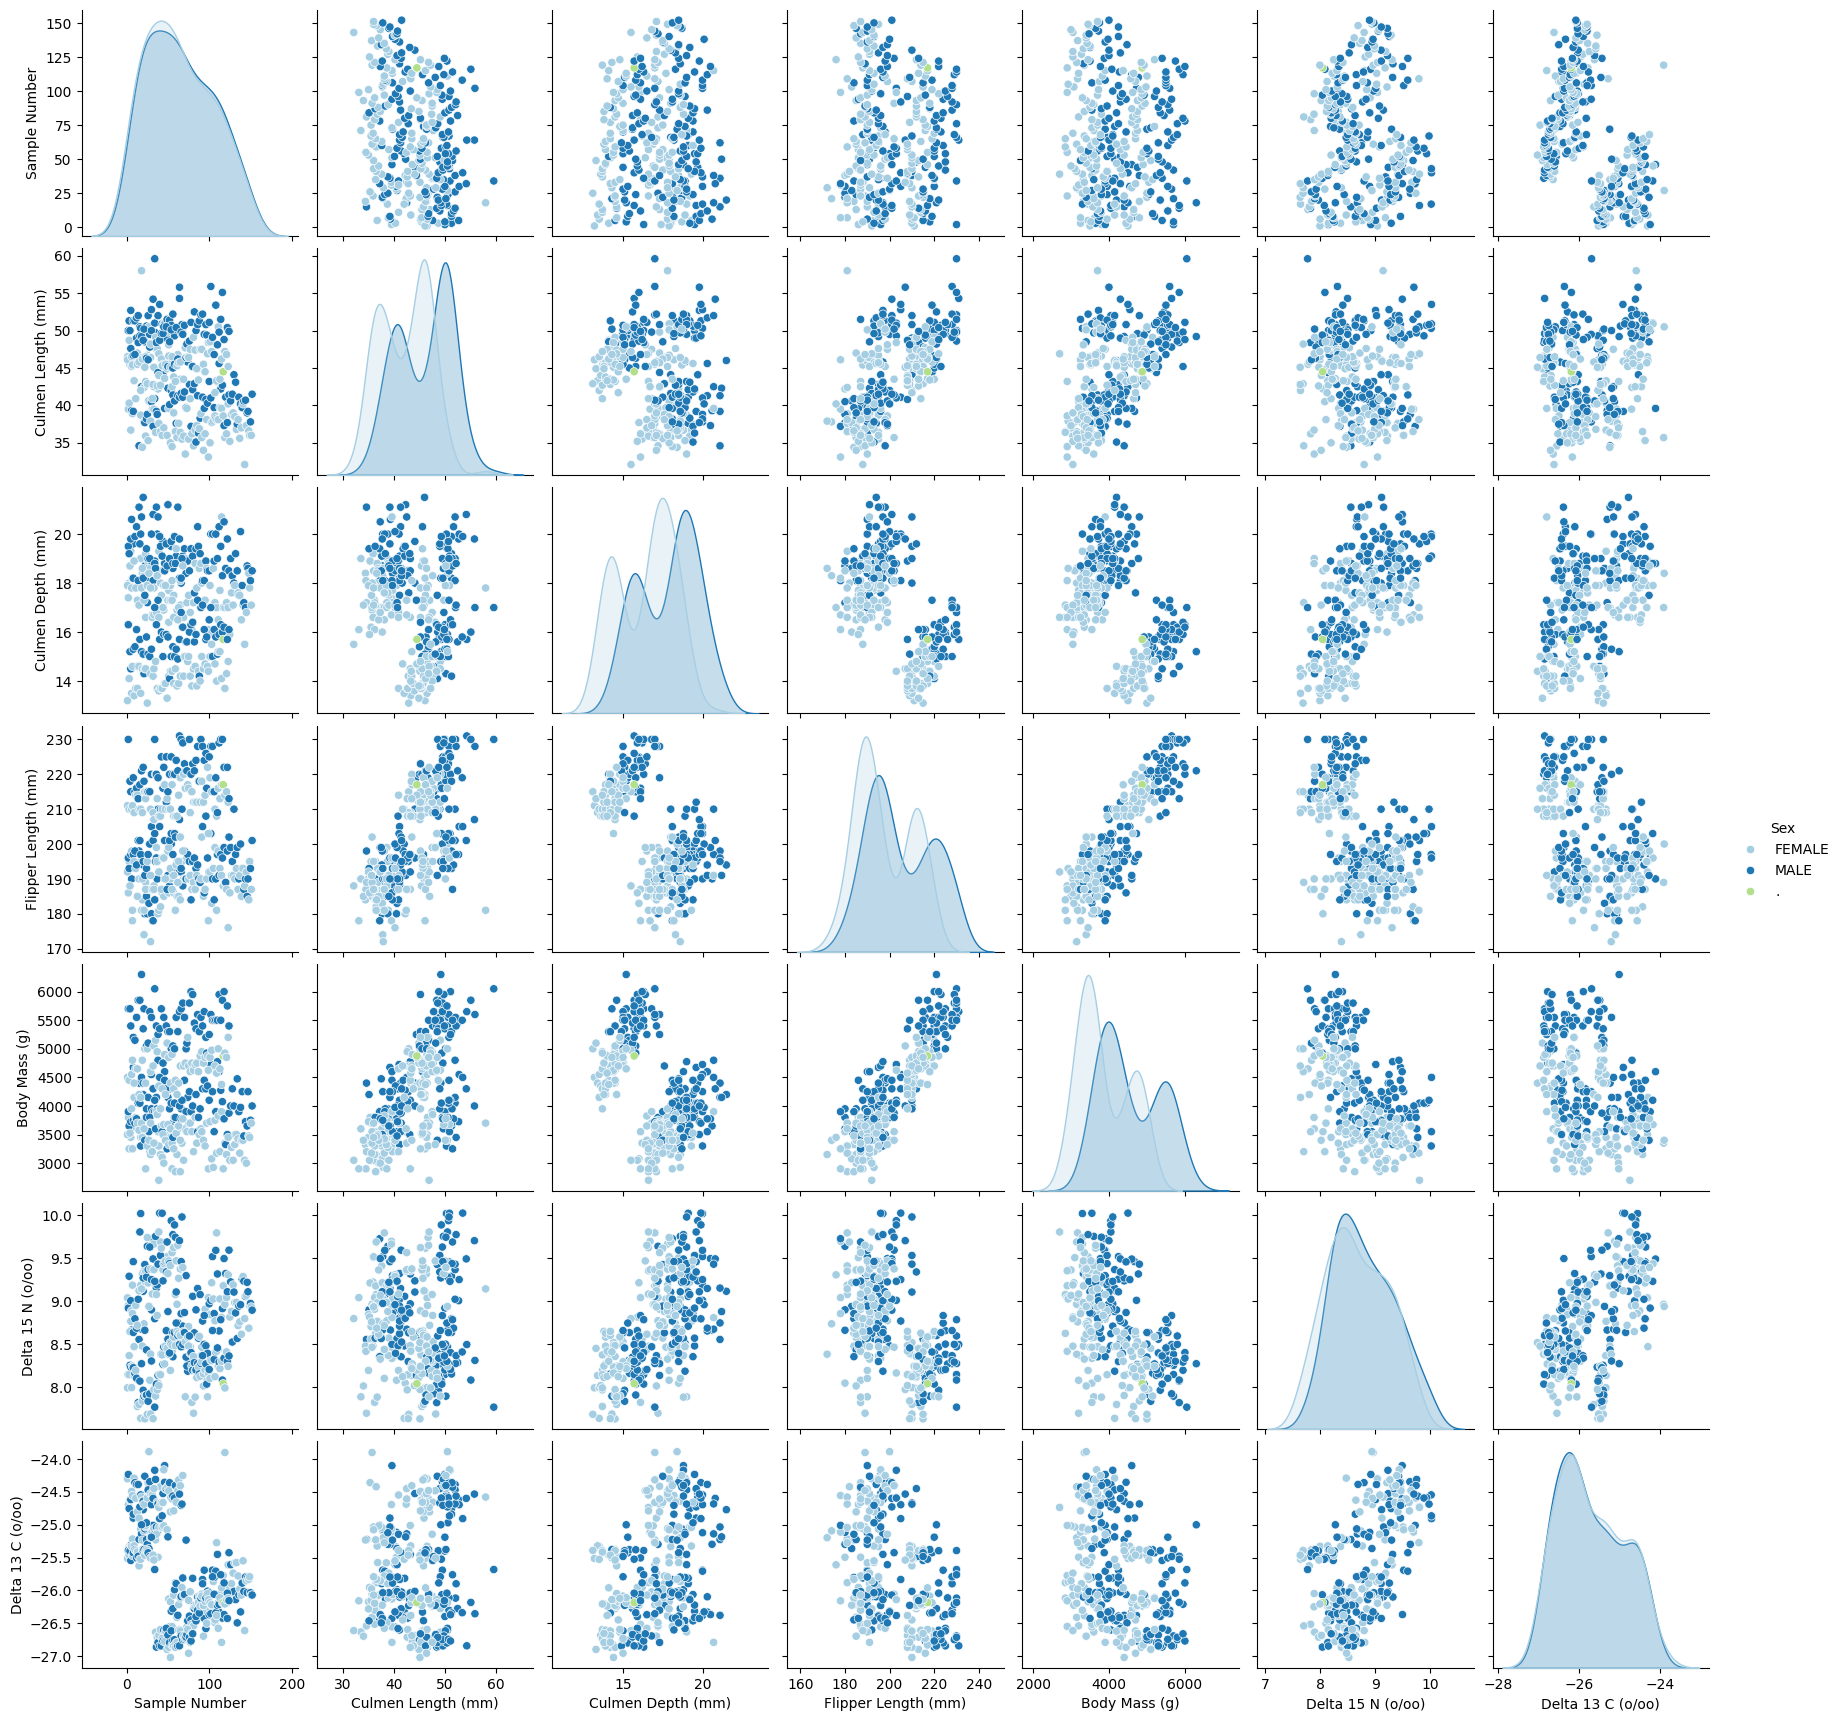

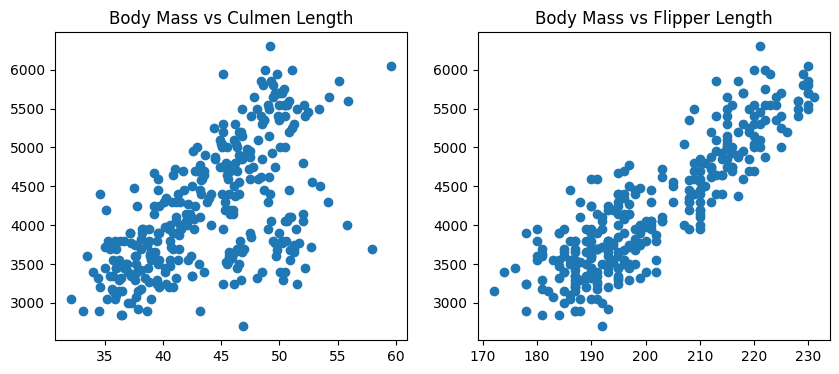

In [10]:
import seaborn as sns
sns.pairplot(df, hue = 'Sex', palette = "Paired")

# Representación variables
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].scatter(df['Culmen Length (mm)'], df['Body Mass (g)'])
axes[1].scatter(df['Flipper Length (mm)'], df['Body Mass (g)'])
axes[0].set_title("Body Mass vs Culmen Length")
axes[1].set_title("Body Mass vs Flipper Length")
plt.show()

# Polynomial Regression

Mean Squared Error: 136445.907980772
R^2 Score: 0.8014197381117604


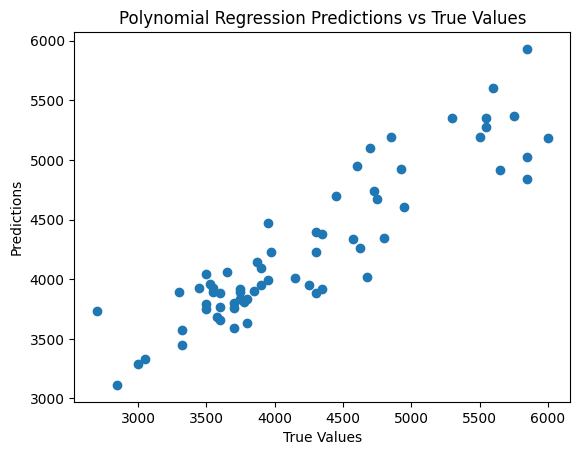

In [21]:
# Graficamos los datos correspondientes
# Para calcular el sexo se puede hacer esto, pero los resultados no son buenos. ¿Por que?
df['Sex']=df['Sex'].astype('category').cat.codes
X_p = df[['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)','Body Mass (g)']]

# Definimos los datos correspondientes a las etiquetas
y_p = df[['Sex']]

# Otra regresión polinomial usando datos cuantitativos
X_p = df[['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)']]

# Definimos los datos correspondientes a las etiquetas
y_p = df[['Body Mass (g)']]

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
# Creamos características polinomiales de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
# Entrenamos el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train_poly, y_train)
# Hacemos predicciones
y_pred = model.predict(X_test_poly)
# Evaluamos el modelo
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {model.score(X_test_poly, y_test)}')

# Grafico
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Polynomial Regression Predictions vs True Values')
plt.show()

# SVC and Random Forest

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Feature
X_p = df[['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)','Body Mass (g)']]
# Definimos los datos correspondientes a las etiquetas
y_p = df[['Sex']]

# SVC y Standard Scaler
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
# Escalamos las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Entrenamos el modelo SVC
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svc_model.fit(X_train_scaled, y_train.values.ravel())
# Hacemos predicciones
ypred = svc_model.predict(X_test_scaled)



# Confusion matrix and accuracy
cm = confusion_matrix(y_test, ypred)
print("Confusion Matrix")
print(cm)
accuracy_score(y_test, ypred)

Confusion Matrix
[[26  7]
 [ 1 31]]


0.8769230769230769

In [28]:
y_p.info()

<class 'pandas.core.series.Series'>
Index: 325 entries, 1 to 343
Series name: Sex
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 5.1 KB


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  # Usamos Classifier, no Regressor
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Limpieza: Eliminamos filas donde 'Sex' (o las features) sea NaN
# Creamos una copia para no afectar el df original si lo usas luego
# 1. Limpieza inicial de nulos estándar
df_clean = df.dropna(subset=['Sex', 'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']).copy()

# 2. IMPORTANTE: Eliminar la fila que tiene el punto '.'
df_clean = df_clean[df_clean['Sex'] != '.']

# 3. Features y Target
X_p = df_clean[['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)','Body Mass (g)']]

# Ahora el map funcionará perfecto porque solo quedan FEMALE y MALE
y_p = df_clean['Sex'].map({'FEMALE': 0, 'MALE': 1})

# 3. Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

# 4. Escalamos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenamos el modelo (Classifier es nativo para esto)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 6. Predicciones
# Con Classifier, predict devuelve directamente 0 o 1, no necesitas el umbral > 0.5
y_pred = rf_model.predict(X_test_scaled)

# Evaluación
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix
[[24  5]
 [ 0 36]]
Accuracy: 0.9230769230769231
